# Regresor con árbol de decisión

En términos de código, implementar un árbol de regresión es bastante parecido a implementar un árbol de decisión para clasificación. Las únicas diferencias estarían en la clase que se importa, en el criterio de selección de nodos, y en la métrica de evaluación. Vamos a ver un ejemplo.

In [ ]:
import pandas as pd

df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data',
    sep=r'\s+',
    header=None,
    names =  ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
              'model year', 'origin', 'car name'],
    na_values='?'
    )

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


**Los árboles funcionan con datasets que tienen datos nulos.**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['mpg', 'car name'], axis=1)
y = df[['mpg']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 278 entries, 350 to 37
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     278 non-null    int64  
 1   displacement  278 non-null    float64
 2   horsepower    273 non-null    float64
 3   weight        278 non-null    float64
 4   acceleration  278 non-null    float64
 5   model year    278 non-null    int64  
 6   origin        278 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 17.4 KB


In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    random_state=1,
    )

model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

In [ ]:
from sklearn.metrics import root_mean_squared_error

print(f'Error de entrenamiento: {root_mean_squared_error(y_train, model.predict(X_train)):.3f}')
print(f'Error de prueba: {root_mean_squared_error(y_test, model.predict(X_test)):.3f}')

Error de entrenamiento: 0.216
Error de prueba: 3.973


¡Los árboles sin podar siempre se sobreajustan!

Los árboles son modelos de **caja blanca**, o explicables. Un modelo de caja blanca (o *white-box model*) en aprendizaje de máquina es un tipo de modelo cuyo funcionamiento interno es transparente y comprensible para las personas. Por eso también se le llama modelo explicable o interpretable.  En un árbol las decisiones se representan como reglas tipo “si-entonces”.

In [ ]:
from sklearn.tree import export_text
r = export_text(model, feature_names=list(X.columns.values))
print(r)

|--- cylinders <= 5.50
|   |--- horsepower <= 71.50
|   |   |--- model year <= 77.50
|   |   |   |--- weight <= 2119.00
|   |   |   |   |--- origin <= 2.50
|   |   |   |   |   |--- model year <= 76.50
|   |   |   |   |   |   |--- weight <= 1981.50
|   |   |   |   |   |   |   |--- model year <= 74.50
|   |   |   |   |   |   |   |   |--- weight <= 1834.50
|   |   |   |   |   |   |   |   |   |--- value: [27.00]
|   |   |   |   |   |   |   |   |--- weight >  1834.50
|   |   |   |   |   |   |   |   |   |--- value: [26.00]
|   |   |   |   |   |   |   |--- model year >  74.50
|   |   |   |   |   |   |   |   |--- displacement <= 93.50
|   |   |   |   |   |   |   |   |   |--- value: [29.00]
|   |   |   |   |   |   |   |   |--- displacement >  93.50
|   |   |   |   |   |   |   |   |   |--- value: [29.50]
|   |   |   |   |   |   |--- weight >  1981.50
|   |   |   |   |   |   |   |--- displacement <= 82.00
|   |   |   |   |   |   |   |   |--- weight <= 2037.00
|   |   |   |   |   |   |   |   |   |

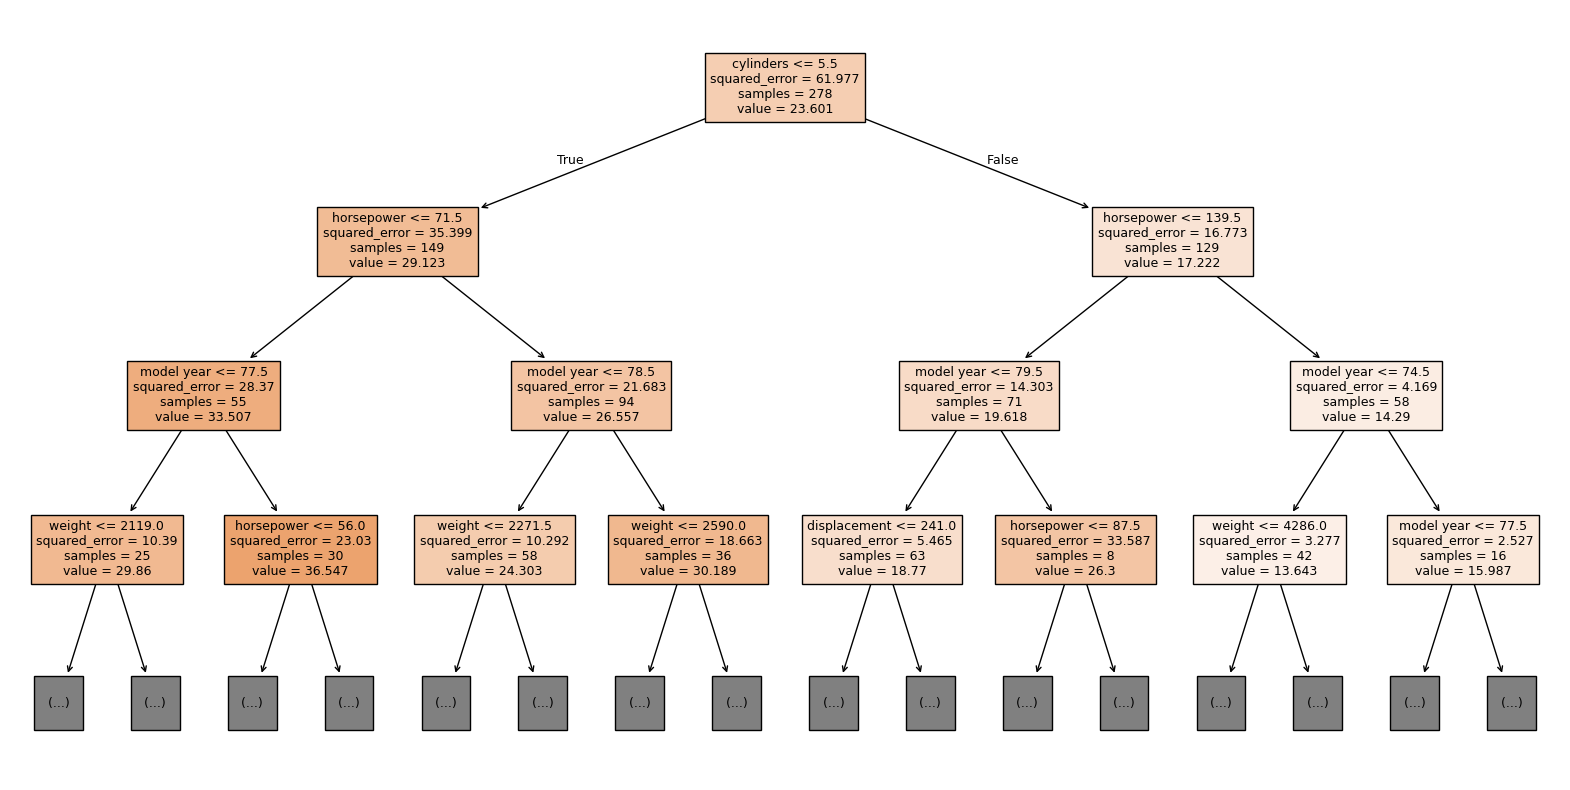

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    max_depth=3,
    filled=True,
    feature_names=X.columns,
    fontsize=9
   )
plt.show();

In [ ]:
model = DecisionTreeRegressor(
    random_state=1,
    max_depth=3
    )

model.fit(X_train, y_train)

print(f'Error de entrenamiento: {root_mean_squared_error(y_train, model.predict(X_train)):.3f}')
print(f'Error de prueba: {root_mean_squared_error(y_test, model.predict(X_test)):.3f}')

Error de entrenamiento: 3.291
Error de prueba: 3.510


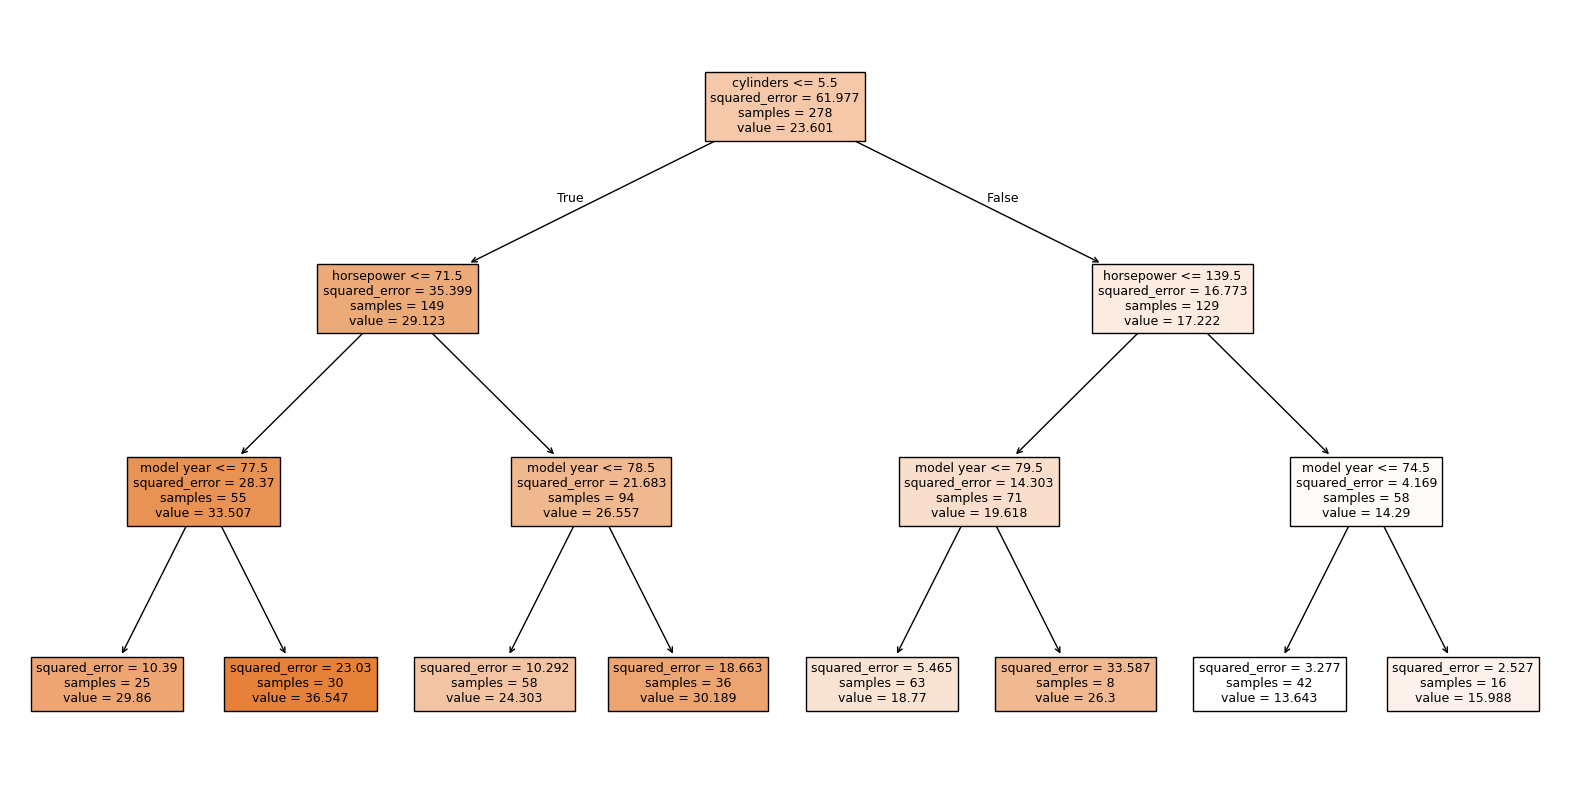

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(model, filled=True, feature_names=X.columns, fontsize=9)
plt.show();

## Con podado

In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV

grid = {'ccp_alpha':np.logspace(-3, 3)}
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=1),
    param_grid=grid,
    scoring='neg_root_mean_squared_error'
    )

grid_search.fit(X_train, y_train)

print(f'Best RMSE: {-grid_search.best_score_:.2f} with {grid_search.best_params_}')
print(f'Train RMSE: {-grid_search.score(X_train, y_train):.2f}')
print(f'Test RMSE: {-grid_search.score(X_test, y_test):.2f}')

Best RMSE: 3.54 with {'ccp_alpha': np.float64(0.28117686979742307)}
Train RMSE: 2.41
Test RMSE: 3.90


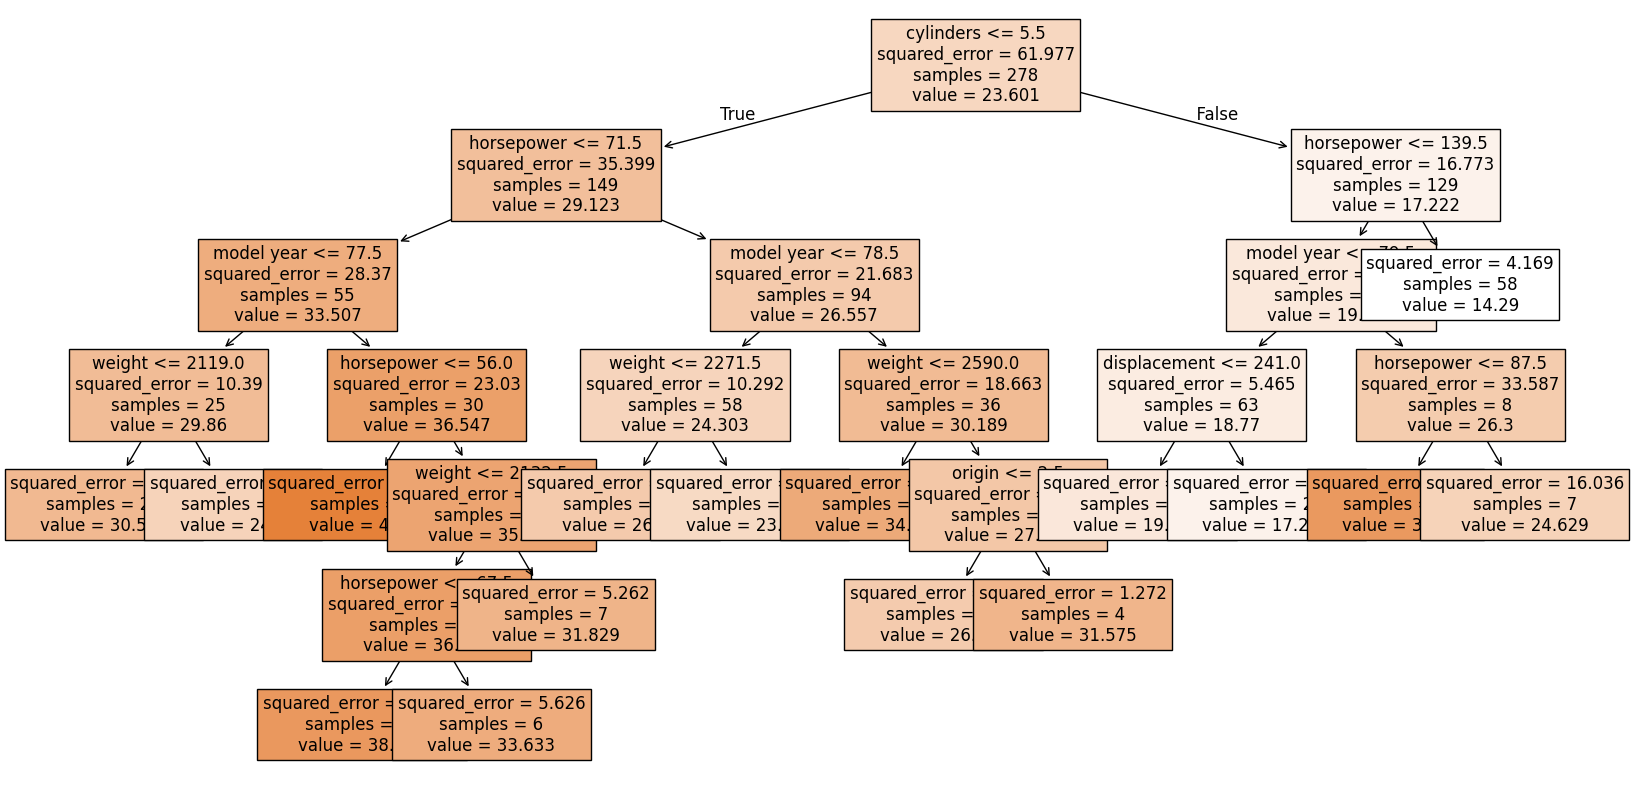

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(grid_search.best_estimator_, filled=True, feature_names=X.columns, fontsize=12)
plt.show();

In [ ]:
df_features = pd.DataFrame({'Feature': X.columns, 'Importance': grid_search.best_estimator_.feature_importances_})
df_features.sort_values('Importance', ascending=False)

,Feature,Importance
0,cylinders,0.627083
2,horsepower,0.196084
5,model year,0.114102
3,weight,0.050951
1,displacement,0.006190
6,origin,0.005592
4,acceleration,0.000000


In [ ]:
grid = {
    'max_depth': np.arange(3,8),
    #'min_samples_split': np.arange(2, 10),
    'min_samples_leaf': np.arange(1, 10)
    }

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=1),
    param_grid=grid,
    scoring='neg_root_mean_squared_error'
    )

grid_search.fit(X_train, y_train)

print(f'Best RMSE: {-grid_search.best_score_:.2f} with {grid_search.best_params_}')
print(f'Train RMSE: {-grid_search.score(X_train, y_train):.2f}')
print(f'Test RMSE: {-grid_search.score(X_test, y_test):.2f}')

Best RMSE: 3.39 with {'max_depth': np.int64(6), 'min_samples_leaf': np.int64(8)}
Train RMSE: 2.41
Test RMSE: 3.41


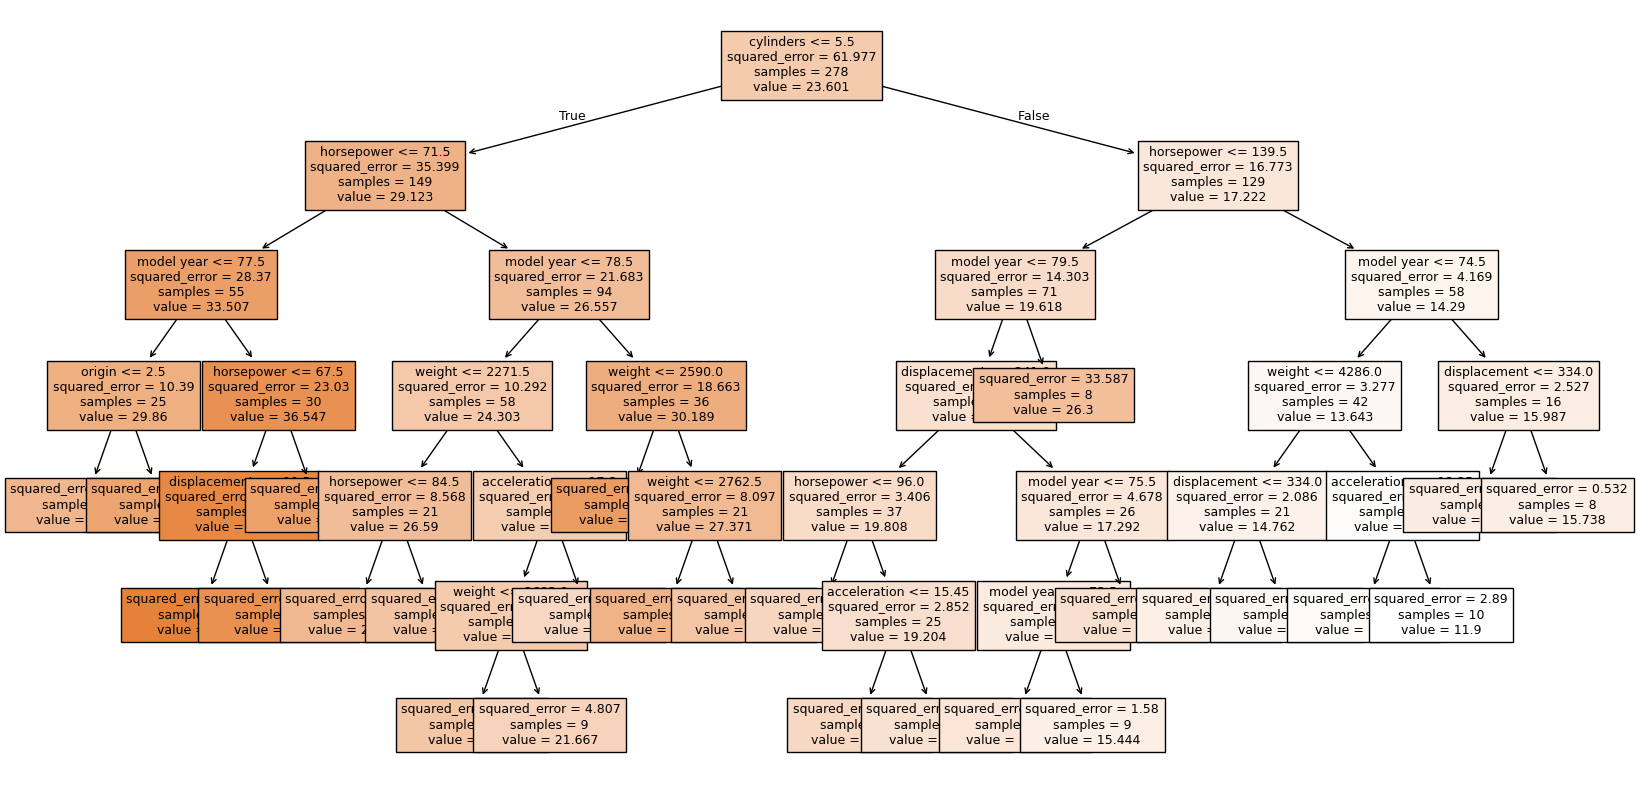

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    grid_search.best_estimator_,
    filled=True,
    feature_names=X.columns, fontsize=9
    )
plt.show();

In [ ]:
df_features = pd.DataFrame({'Feature': X.columns, 'Importance': grid_search.best_estimator_.feature_importances_})
df_features.sort_values('Importance', ascending=False)

,Feature,Importance
0,cylinders,0.626818
2,horsepower,0.181285
5,model year,0.121543
3,weight,0.048525
1,displacement,0.010625
6,origin,0.006258
4,acceleration,0.004945


# Con procesamiento de datos numéricos

Vamos a probar sí el modelo mejora procesando datos numéricos

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import root_mean_squared_error

num_vars = ['displacement', 'horsepower', 'weight', 'acceleration'] # Se definen las variables numéricas
ohe = OneHotEncoder(sparse_output=False, drop='first')
oe_cyl = OrdinalEncoder(categories=[[3., 4., 5., 6., 8.]])
oe_my = OrdinalEncoder(categories=[[70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81., 82.]])
ss = StandardScaler()

preprocessor = ColumnTransformer(transformers=[('ohe', ohe, ['origin']), # Codificacióp OneHot para la variable 'origin'
                                               ('oe_cylinders', oe_cyl, ['cylinders']), # Codificación ordinal para la variable 'cylinders'
                                               ('oe_model_year', oe_my, ['model year']), # Codificación ordinal para la variable 'model_year'
                                               ('ss', ss, num_vars)], # Prepocesamiento de las variables numéricas
                                               remainder='passthrough') # El resto de las columnas se mantienen sin cambios

pipe = Pipeline([('preprocessor', preprocessor), ('model', DecisionTreeRegressor(random_state=1))]) # Se define un pipeline con el preprocesador y el modelo Ridge
grid = {'model__ccp_alpha':np.logspace(-3,3)}
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=grid,
    scoring='neg_root_mean_squared_error'
    )
grid_search.fit(X_train, y_train)

print(f'Best RMSE: {-grid_search.best_score_:.2f} with {grid_search.best_params_}')
print(f'Train RMSE: {-grid_search.score(X_train, y_train):.2f}')
print(f'Test RMSE: {-grid_search.score(X_test, y_test):.2f}')

Best RMSE: 3.54 with {'model__ccp_alpha': np.float64(0.28117686979742307)}
Train RMSE: 2.41
Test RMSE: 3.90


**La estandarización de datos generalmente no mejora el desempeño de los árboles de decisión de manera significativa.**

### ¿Por qué?

* **Invariante a escalamiento:** Los árboles de decisión basan sus decisiones en la creación de umbrales en las características. Estos umbrales se ajustan automáticamente a la escala de cada característica. Por lo tanto, si escalamos los datos, los umbrales simplemente se ajustarán en proporción, sin afectar el resultado final.
* **Importancia relativa:** Lo que realmente importa en un árbol de decisión es la importancia relativa de cada característica, no su escala absoluta. Si una característica tiene una mayor varianza que otra, esto simplemente significa que es más importante para la toma de decisiones.

### ¿Cuándo podría ser útil la estandarización?

* **Comparación con otros modelos:** Si se desea comparar el rendimiento de un árbol de decisión con otros modelos que sí se ven afectados por la escala de los datos (como las redes neuronales o los métodos lineales), es recomendable estandarizar los datos para que la comparación sea justa.
* **Algoritmos híbridos:** En algunos casos, los árboles de decisión se utilizan como parte de algoritmos más complejos que sí se benefician de la estandarización.
* **Preprocesamiento adicional:** Si se planea aplicar otras técnicas de preprocesamiento, como la reducción de dimensionalidad, la estandarización puede ser un paso previo útil.

### Conclusiones

En general, la estandarización no es un paso necesario para entrenar árboles de decisión. Sin embargo, puede ser útil en ciertas situaciones específicas, como cuando se comparan con otros modelos o cuando se realizan preprocesamientos adicionales.

**Es importante destacar que cada conjunto de datos es único y los resultados pueden variar.** Siempre es recomendable experimentar con diferentes técnicas de preprocesamiento para encontrar la mejor configuración para tu problema específico.
